# Game of Life Mosaics - Quick Start

This notebook demonstrates how to create your first Game of Life mosaic in just a few lines of code.

## What we'll do:
1. Import the library
2. Create a mosaic generator
3. Generate a mosaic from an image
4. Display and save the result

## Setup

First, import the required libraries:

In [1]:
# Import libraries
import matplotlib.pyplot as plt
from PIL import Image

# Import gol_mosaics (installed with: pip install -e .)
from gol_mosaics import MosaicGenerator, ImageProcessor

%load_ext autoreload
%autoreload 2

## Step 1: Load and prepare the image

We'll use a raw colour photograph of the inventor of the Game of Life,
**John Horton Conway** — background and all.

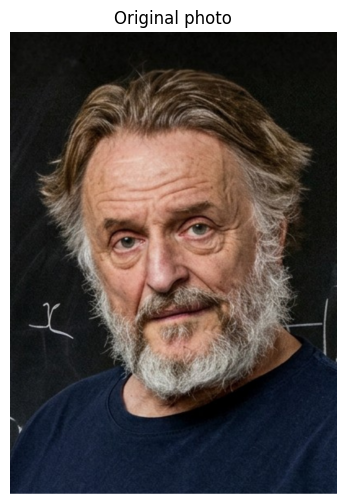

In [2]:
# Raw colour photo, with its original background
input_path = '../input/images/john-original.png'
original = Image.open(input_path)

plt.figure(figsize=(6, 6))
plt.imshow(original)
plt.title('Original photo')
plt.axis('off')
plt.show()

The mosaic works from a **greyscale image with the background removed and the
contrast boosted**. `ImageProcessor.load_image` does all of that in one step
(automatic background removal + greyscale + an S-curve contrast boost), and
`generate_from_image` calls it for you. To see each stage and how to tune it,
open [`preprocessing_demo.ipynb`](preprocessing_demo.ipynb).

_NOTE_: you can use your own image — a portrait with a clear subject works best.
If it already has a transparent background it is used as-is.

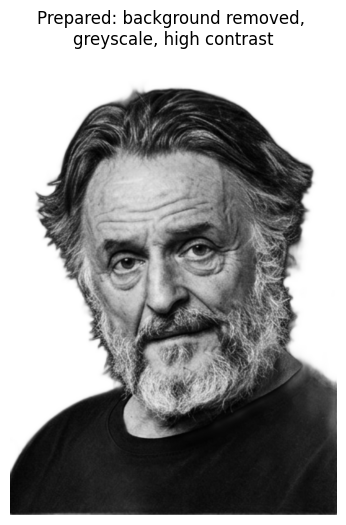

In [4]:
# One call: automatic background removal + greyscale + contrast boost
prepped = ImageProcessor.load_image(input_path)

plt.figure(figsize=(6, 6))
plt.imshow(prepped, cmap='gray')
plt.title('Prepared: background removed, \ngreyscale, high contrast')
plt.axis('off')
plt.show()

## Step 2: Create Mosaic Generator

Create a generator with default (randomised) settings:

In [16]:
# Create generator with default randomised settings
# This will use UGent colours (blue and yellow)

generator = MosaicGenerator()

print(f"Generator created: {generator}")
print()
print(f"Pattern library will be loaded with Still Life Tiles of level {generator.level}")
print(f"Grid height: {generator.grid_size} tiles")
print(f"The background will contain patterns created by the elementary CA with rule {generator.eca_rule}")

Generator created: MosaicGenerator(level=4, grid_size=80, eca_rule=54)

Pattern library will be loaded with Still Life Tiles of level 4
Grid height: 80 tiles
The background will contain patterns created by the elementary CA with rule 54


## Step 3: Generate Mosaic

Now the magic happens - convert the image to a Game of Life mosaic!

Note: if your `grid_size` and `level` values are high, this can take a while.

In [17]:
# Generate mosaic (this may take a few seconds)
# No parameters needed - supersample and ECA rule are auto-selected!
print("Generating mosaic...")
print()
mosaic = generator.generate_from_image(input_path)
print(f"Done!")
print(f"Mosaic size: {mosaic.size}")
print(f"Selected ECA rule: {generator.eca_rule}")

Generating mosaic...

Done!
Mosaic size: (984, 1368)
Selected ECA rule: 54


We simply used all default settings, which implies that random values are selected for the various input parameters, except for the colours; these follow the palette of the University of Ghent (Belgium).

For more information on the effect of the various parameters, see the `parameter_demo.ipynb` Notebook.

## Step 4: Display the Result

Let's see our Game of Life mosaic!

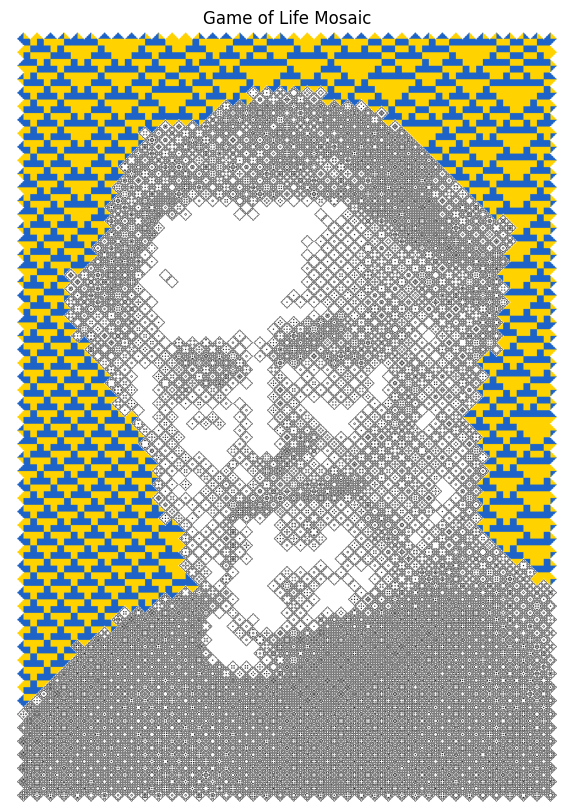

In [18]:
# Display mosaic
plt.figure(figsize=(10, 10))
plt.imshow(mosaic)
plt.title('Game of Life Mosaic')
plt.axis('off')
plt.show()

If you like, try creating a slightly different one (with a different background or different resolution) by returning to Step 3 and creating a generator object with different random settings.

## Step 5: Save the Result

Save the mosaic to a file, if you like.

In [19]:
# Set to True to save the mosaic to the output directory
SAVEFIG = False

# Save to output directory
if SAVEFIG:
    output_path = '../output/images/quickstart_mosaic.png'
    mosaic.save(output_path)
    print(f"Mosaic saved to: {output_path}")
else:
    print("Mosaic not saved. Set SAVEFIG = True to save the mosaic to the output directory.")

Mosaic not saved. Set SAVEFIG = True to save the mosaic to the output directory.


## That's it!

You've created your first Game of Life mosaic. The complete process was:

```python
from gol_mosaics import MosaicGenerator

generator = MosaicGenerator()
mosaic = generator.generate_from_image('input.png')
mosaic.save('output.png')
```

## Next Step

Get acquainted with the various parameters in the Notbook `parameter_demo.ipynb`, and try experimenting with different parameters in the Notebook `playground.ipynb`.
- Different `level` values (2, 3, 4, or 5)
- Different `grid_size` values (higher = more detail)
- Different threshold values for the alpha channel and the background cut-off
- Custom colours with `ColorScheme`
- Different ECA rules (30, 45, 54, 106, 110, etc.)

## Advanced

If you want to animate the collapse of a Still Life, you may want to take a look at the `golly.ipynb` Notebook. And if you want to start doing some coding yourself, you may want to solve some open problems within this repository, a number of which are listed in the `open_problems.ipynb` Notebook. In case you want to know how the Tiles are created, consult the `tile_generation.ipynb` Notebook.

Enjoy!